In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from features.Carl import (feature_total_pages_count,
           total_number_of_sessions,
           time_last_used,
           last_level_of_each_customer,
           usage_metrices,
           num_status,
           exact_device_type,
           gender_feature_ont_hot,
           location_state_one_hot_encoded,
           member_since,
           num_different_songs,
           num_different_artists)
from pipeline import create_X_y_df

import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report

In [3]:
np.random.seed(42)

In [5]:
full_dataset_df = pd.read_parquet("../../../data/churn-prediction-25-26/train.parquet")

In [6]:
full_dataset_df.sample(10)

# status -> Nelson
# gender -> Carl
# level -> Nelson
# ts -> Carl
# page -> Nelson
# location -> Carl
# itemInSession -> Nelson
# userAgent -> Carl
# method -> Nelson
# length -> Carl
# song -> Nelson
# artist -> Nelson
# time -> Carl
# registration -> Carl

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration
8415245,200,M,August,paid,Clark,1207487,1540518498000,Logged In,NextSong,112798,"Riverside-San Bernardino-Ontario, CA",400,Mozilla/5.0 (Windows NT 6.1; Trident/7.0; rv:1...,PUT,236.04200,Hostile [Live Version],Pantera,2018-10-26 01:48:18,2018-09-10 17:03:47
12828473,200,F,Alani,paid,Kane,1325330,1541672419000,Logged In,NextSong,159518,"Tampa-St. Petersburg-Clearwater, FL",74,Mozilla/5.0 (Windows NT 6.1; rv:31.0) Gecko/20...,PUT,194.03710,Karibien,Air France,2018-11-08 10:20:19,2018-09-05 06:02:19
13490632,200,F,Angelina,paid,Singh,1495032,1541826321000,Logged In,NextSong,174513,"Santa Maria-Santa Barbara, CA",216,"""Mozilla/5.0 (iPhone; CPU iPhone OS 7_1_2 like...",PUT,278.07302,Through The Wire,Kanye West,2018-11-10 05:05:21,2018-08-24 13:24:27
9329450,200,M,Nathaniel,paid,Norris,1525270,1540794304000,Logged In,NextSong,128771,"San Francisco-Oakland-Hayward, CA",120,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,132.85832,Ride A White Swan,T. Rex,2018-10-29 06:25:04,2018-06-23 13:42:06
13901146,200,M,Landyn,paid,Evans,1849720,1541985370000,Logged In,NextSong,179047,"Atlanta-Sandy Springs-Roswell, GA",74,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,266.65751,Black Planet (Remastered),Sisters Of Mercy,2018-11-12 01:16:10,2018-08-25 21:44:42
930473,200,F,Alondra,paid,Johnson,1981365,1538601966000,Logged In,NextSong,35505,"Houston-The Woodlands-Sugar Land, TX",255,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.6; r...,PUT,579.83955,Kalopsia,Mark Otten,2018-10-03 21:26:06,2018-08-26 05:10:08
23244814,200,F,Georgia,paid,Walsh,1558947,1538958297000,Logged In,NextSong,7989,"Dallas-Fort Worth-Arlington, TX",12,"""Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/5...",PUT,201.79546,Revelry,Kings Of Leon,2018-10-08 00:24:57,2018-09-10 19:59:11
9200665,200,M,Jadon,paid,Benitez,1999781,1540750023000,Logged In,NextSong,132052,"San Diego-Carlsbad, CA",49,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.9; r...,PUT,98.14159,Samba De Una Nota SoÃÂ´,Joa~o Gilberto,2018-10-28 18:07:03,2018-08-31 02:26:28
5698983,200,F,Fatima,free,Hancock,1460110,1539845728000,Logged In,NextSong,74377,"New York-Newark-Jersey City, NY-NJ-PA",12,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,244.47955,Chana Masala,Looptroop,2018-10-18 06:55:28,2018-09-06 14:24:41
7062194,200,M,James,paid,Carlson,1588321,1540221175000,Logged In,NextSong,107607,"Cleveland-Elyria, OH",11,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:31....,PUT,218.27873,Tonight,FM Static,2018-10-22 15:12:55,2018-09-25 02:33:43


In [7]:
# Second Train Test set
cut_off_date_train = pd.Timestamp("2018-10-29")
cut_off_date_test = pd.Timestamp("2018-11-18")

df_X, df_y = create_X_y_df(df = full_dataset_df,
                                t0=cut_off_date_train,
                                t1=cut_off_date_test)

In [8]:
def create_feature_engineered_df(df):
    feature_total_pages_count_df = feature_total_pages_count(df)
    total_number_of_sessions_df = total_number_of_sessions(df)
    time_last_used_df = time_last_used(df)
    last_level_of_each_customer_df = last_level_of_each_customer(df)
    usage_metrices_df = usage_metrices(df)
    num_status_df = num_status(df)
    device_type_df = exact_device_type(df)
    gender_feature_ont_hot_df = gender_feature_ont_hot(df)
    location_state_one_hot_encoded_df = location_state_one_hot_encoded(df)
    member_since_df = member_since(df)
    num_different_songs_df = num_different_songs(df)
    num_different_artists_df = num_different_artists(df)


    df = feature_total_pages_count_df.merge(total_number_of_sessions_df,
                                            on = "userId")

    df = df.merge(time_last_used_df, on = "userId")
    df = df.merge(last_level_of_each_customer_df, on = "userId")
    df = df.merge(usage_metrices_df, on = "userId")
    df = df.merge(num_status_df, on = "userId")
    df = df.merge(device_type_df, on = "userId")
    df = df.merge(gender_feature_ont_hot_df, on = "userId")
    df = df.merge(location_state_one_hot_encoded_df, on = "userId")
    df = df.merge(member_since_df, on = "userId")
    df = df.merge(num_different_songs_df, on = "userId")
    df = df.merge(num_different_artists_df, on = "userId")

    return df


df_X_features = create_feature_engineered_df(df_X)

/Users/aaron/Desktop/1_Studium/1_Master/1_Polytechnique/1_Courses/4_Python_for_Data_Science/2_Kaggle_Challenge/kaggle_challenge/src/features/Carl/device_used.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_b.loc[:, "val"] = np.ones(len(df_b))


In [9]:
df_X_features

,userId,About,Add Friend,Add to Playlist,Downgrade,Error,Help,Home,Logout,NextSong,...,UT,VA,VT,WA,WI,WV,WY,member_since,num_different_songs,num_different_artists
0,1000035,2.0,14.0,15.0,1.0,0.0,3.0,28.0,9.0,692.0,...,0,0,0,0,0,0,0,46,654,564
1,1000103,0.0,0.0,1.0,1.0,0.0,0.0,5.0,2.0,52.0,...,0,0,0,0,0,0,0,36,53,52
2,1000164,1.0,5.0,10.0,0.0,0.0,2.0,15.0,3.0,368.0,...,0,0,0,0,0,0,0,77,351,320
3,1000168,0.0,10.0,10.0,1.0,0.0,2.0,18.0,6.0,351.0,...,0,0,0,0,0,0,0,81,343,312
4,1000182,0.0,1.0,6.0,2.0,0.0,0.0,4.0,1.0,115.0,...,0,0,0,0,1,0,0,117,115,106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15558,1999241,2.0,3.0,3.0,0.0,0.0,1.0,10.0,4.0,205.0,...,0,0,0,0,0,0,0,31,201,194
15559,1999382,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,32.0,...,0,0,0,0,0,0,0,30,33,33
15560,1999781,3.0,16.0,25.0,1.0,0.0,7.0,42.0,14.0,989.0,...,0,0,0,0,0,0,0,58,923,775
15561,1999848,1.0,9.0,9.0,0.0,1.0,3.0,20.0,7.0,280.0,...,0,0,0,0,0,0,0,58,272,252


In [10]:
df_X_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15563 entries, 0 to 15562
Columns: 106 entries, userId to num_different_artists
dtypes: bool(1), float64(47), int64(56), object(2)
memory usage: 12.5+ MB


In [11]:
df_X_features = df_X_features.sort_values("userId")
df_y = df_y.sort_values("userId")


In [12]:
df_X_features.columns

Index(['userId', 'About', 'Add Friend', 'Add to Playlist', 'Downgrade',
       'Error', 'Help', 'Home', 'Logout', 'NextSong',
       ...
       'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY', 'member_since',
       'num_different_songs', 'num_different_artists'],
      dtype='object', length=106)

In [13]:
df_y.columns

Index(['userId', 'Cancellation Confirmation'], dtype='object')

In [14]:
"""
columns_X = ['About', 'Add Friend', 'Add to Playlist',
              'Downgrade', 'Error', 'Help', 'Home',
       'Logout', 'NextSong', 'Roll Advert', 'Save Settings', 'Settings',
       'Submit Downgrade', 'Submit Upgrade', 'Thumbs Down', 'Thumbs Up',
       'Upgrade', 'total_number_of_sessions', 'time_not_used',
       'mean_tps_minutes', 'mean_tbs_minutes', 'median_tps_minutes',
       'median_tbs_minutes', 'level', 'exact_device']
"""

columns_X = df_X_features.columns.drop(["userId"])


columns_y = "Cancellation Confirmation"

In [15]:
num_cols = df_X_features[columns_X].select_dtypes(include=["int64", "float64"]).\
    columns.tolist()


categorical_columns = df_X_features[columns_X].select_dtypes(include=["object"]).\
    columns.tolist()

preprocesseor_lr=ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), num_cols),
        ("categorical", OneHotEncoder(), categorical_columns),
    ]
)

one_hot_dense_preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore",
                                 sparse_output=False), categorical_columns),
    ],
    remainder="passthrough"
)

model_lr = Pipeline([
    ("prepocesseor", preprocesseor_lr),
    ("model", LogisticRegression(max_iter=10000))#, class_weight={0:1, 1:10}))
])


model_hgbc = Pipeline([
    ("prepocesseor", one_hot_dense_preprocessor),
    ("model", HistGradientBoostingClassifier(max_depth=50))
])

In [16]:
# Remove identifier column before scaling/modeling
X = df_X_features[columns_X]
y = df_y[columns_y]

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [17]:
y_train

12838    0
15179    0
11342    1
14537    0
11184    0
        ..
2850     0
15534    0
6252     0
8635     0
6072     0
Name: Cancellation Confirmation, Length: 11672, dtype: int8

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      3525
           1       0.33      0.04      0.06       366

    accuracy                           0.90      3891
   macro avg       0.62      0.51      0.51      3891
weighted avg       0.85      0.90      0.87      3891



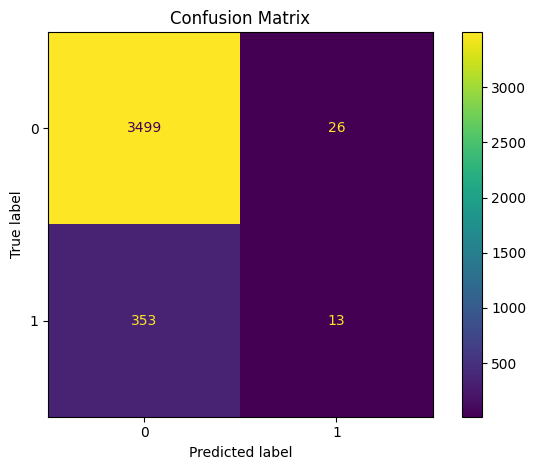

{'fit_time': array([0.9112432 , 0.53303814, 0.49904394, 0.44730377, 0.6371088 ]),
 'score_time': array([0.04800677, 0.03377795, 0.03515887, 0.03256702, 0.03982019]),
 'test_score': array([0.90330871, 0.90266624, 0.90170254, 0.90231362, 0.90199229]),
 'train_score': array([0.92923695, 0.91317269, 0.91277108, 0.91093085, 0.92225524])}

In [18]:
model_hgbc.fit(X_train, y_train)
pred = model_hgbc.predict(X_test)
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
cross_validate(model_hgbc, X, y, return_train_score=True)


#https://scikit-learn.org/stable/modules/ensemble.html#interpretation-with-feature-importance

[[3477   48]
 [ 341   25]]
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      3525
           1       0.34      0.07      0.11       366

    accuracy                           0.90      3891
   macro avg       0.63      0.53      0.53      3891
weighted avg       0.86      0.90      0.87      3891



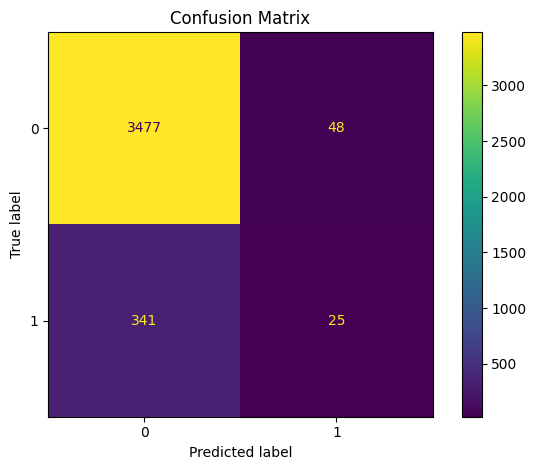

In [19]:


# 2) Preprocess: impute + one-hot for categoricals, impute for numerics
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))  # use sparse output by default
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipeline, categorical_columns),
        ("num", numeric_pipeline, num_cols),
    ],
    remainder="passthrough"
)

# 3) Model
"""xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"  # avoids warning in many setups
)
"""

n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
spw = n_neg / max(n_pos, 1)

#xgb = XGBClassifier(scale_pos_weight = spw, eval_metric="aucpr")
xgb = XGBClassifier()

# 4) Full pipeline
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", xgb)
])

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

# numeric matrix
cm = confusion_matrix(y_test, pred)
print(cm)

print(classification_report(y_test, pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [17]:
cross_validate(clf, X, y, return_train_score=True)

{'fit_time': array([0.39615107, 0.40061378, 0.39246416, 0.38478899, 0.41431808]),
 'score_time': array([0.01081705, 0.01280904, 0.01079822, 0.01194215, 0.0113821 ]),
 'test_score': array([0.95140914, 0.95011338, 0.95011338, 0.9507453 , 0.9507453 ]),
 'train_score': array([0.99781306, 0.99919002, 0.99748907, 0.99870414, 0.9981372 ])}

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

scores = cross_validate(
    clf, X, y,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "f1", "roc_auc"],
    return_train_score=True
)
scores

{'fit_time': array([0.39839411, 0.38926601, 0.38807297, 0.3943429 , 0.39145803]),
 'score_time': array([0.02669287, 0.02529287, 0.02860498, 0.0289731 , 0.02608109]),
 'test_accuracy': array([0.94914156, 0.95076126, 0.95011338, 0.95204148, 0.95042126]),
 'train_accuracy': array([0.99919002, 0.99708408, 0.99781306, 0.99838017, 0.9991091 ]),
 'test_balanced_accuracy': array([0.5047619 , 0.50884354, 0.50204082, 0.52244852, 0.50867295]),
 'train_balanced_accuracy': array([0.9914966 , 0.96938776, 0.97704082, 0.9829932 , 0.99064626]),
 'test_f1': array([0.02484472, 0.03797468, 0.01282051, 0.08641975, 0.03773585]),
 'train_f1': array([0.99142367, 0.96842105, 0.97650131, 0.98269896, 0.99055794]),
 'test_roc_auc': array([0.68030682, 0.69325744, 0.68718127, 0.70652242, 0.70718672]),
 'train_roc_auc': array([1.        , 0.99999913, 0.99999653, 1.        , 1.        ])}

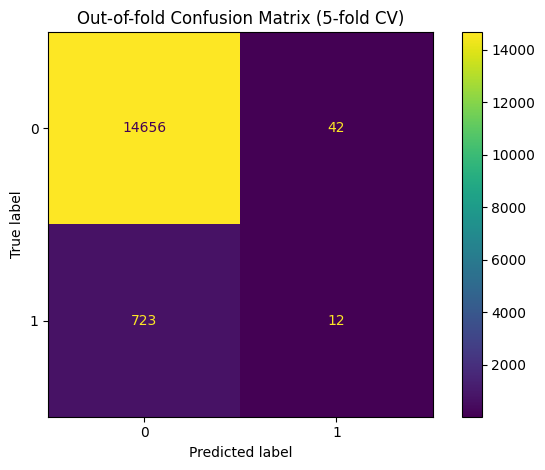

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

oof_pred = cross_val_predict(clf, X, y, cv=cv, method="predict")

ConfusionMatrixDisplay.from_predictions(y, oof_pred, values_format="d")
plt.title("Out-of-fold Confusion Matrix (5-fold CV)")
plt.tight_layout()
plt.show()